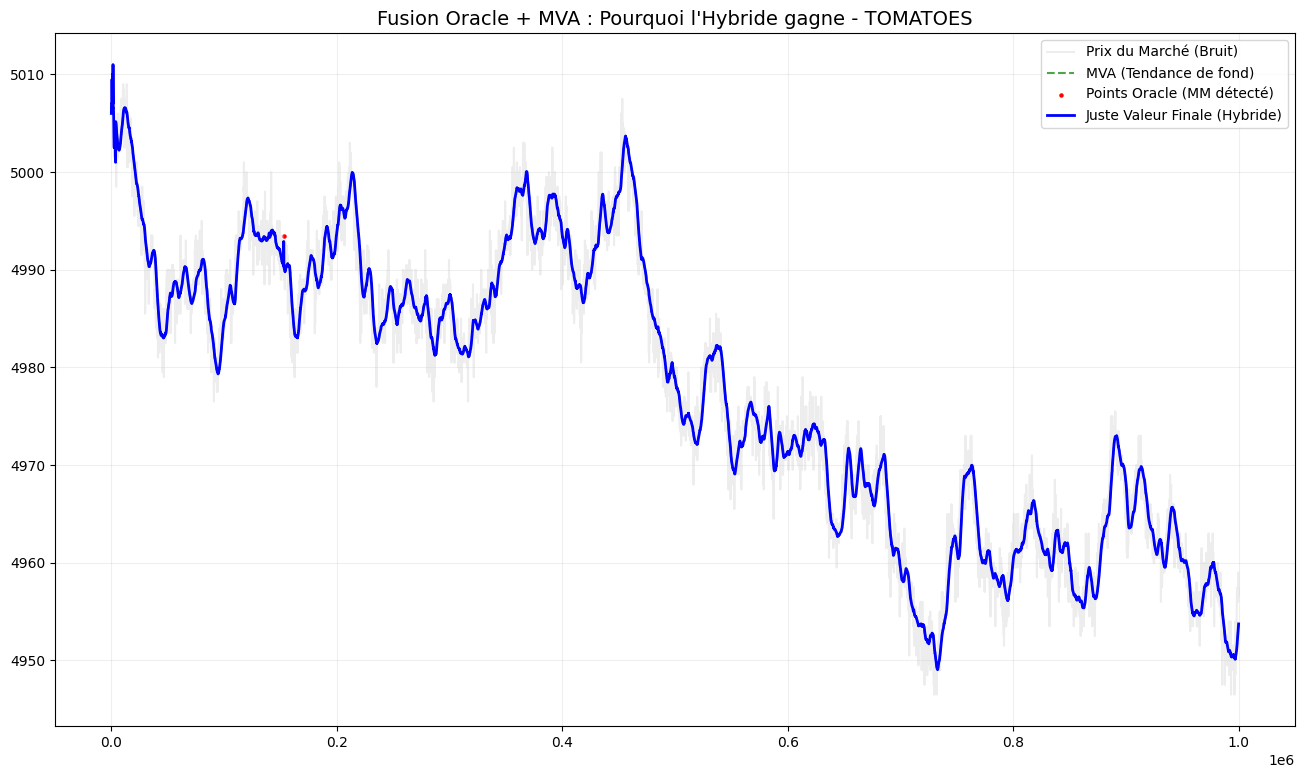

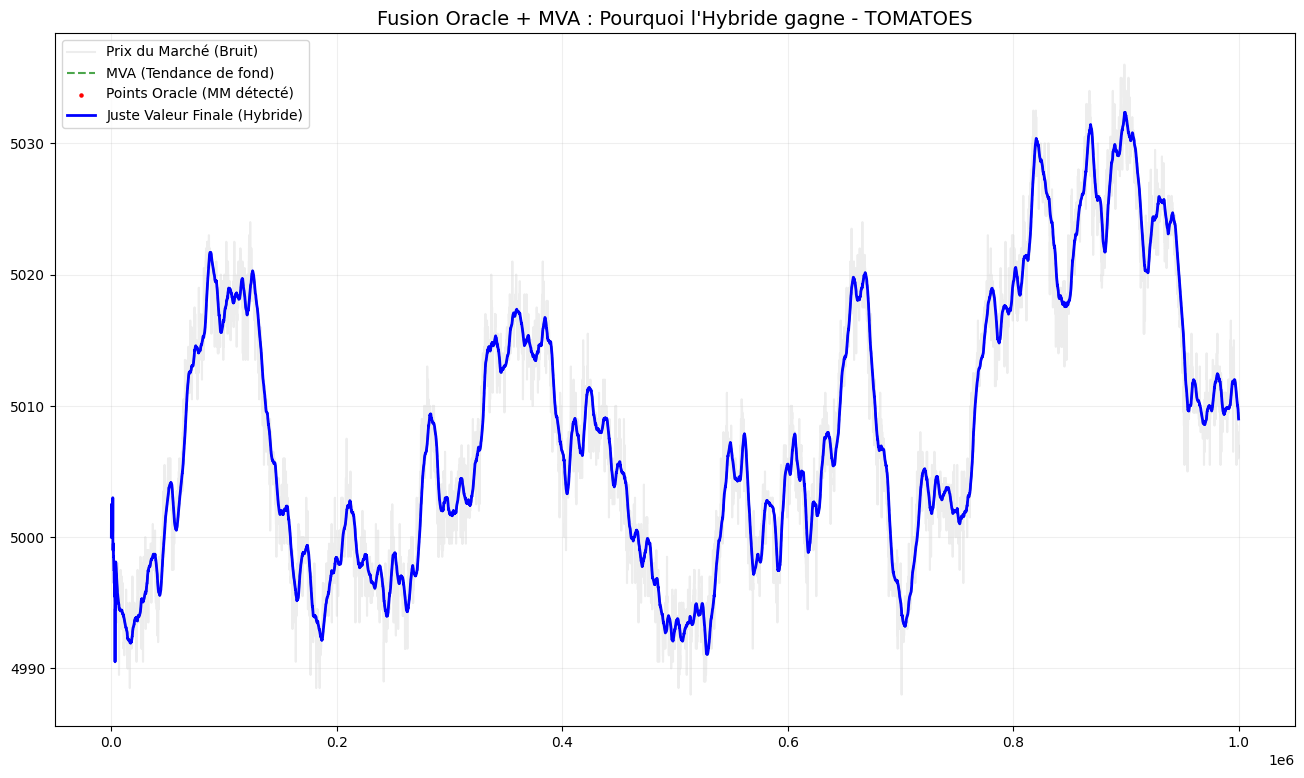

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_hybrid_final(csv_path, product="TOMATOES", window=40):
    df = pd.read_csv(csv_path, sep=';')
    df = df[df['product'] == product].copy().reset_index(drop=True)
    
    # 1. Calcul de la MVA (La base qui ne meurt jamais)
    df['mva'] = df['mid_price'].rolling(window=window).mean()

    # 2. Détection de la Signature (L'Oracle précis mais capricieux)
    oracle_points = []
    for _, row in df.iterrows():
        bids = {row[f'bid_price_{i}']: row[f'bid_volume_{i}'] for i in range(1, 4) if pd.notna(row[f'bid_price_{i}'])}
        asks = {row[f'ask_price_{i}']: abs(row[f'ask_volume_{i}']) for i in range(1, 4) if pd.notna(row[f'ask_price_{i}'])}
        
        found_fv = np.nan
        if bids and asks:
            best_b_p = max(bids.keys(), key=lambda p: bids[p])
            best_a_p = max(asks.keys(), key=lambda p: asks[p])
            if bids[best_b_p] >= 10 and asks[best_a_p] >= 10:
                if 2 <= (best_a_p - best_b_p) <= 10:
                    found_fv = (best_b_p + best_a_p) / 2.0
        oracle_points.append(found_fv)
    
    df['oracle_raw'] = oracle_points

    # 3. Calcul de la Juste Valeur Finale (Hybride)
    # Si l'Oracle est là, on fait un mix (80% Oracle / 20% MVA)
    # Si l'Oracle est absent, on prend 100% MVA
    df['final_fv'] = df['mva']
    mask = df['oracle_raw'].notna()
    df.loc[mask, 'final_fv'] = (df['oracle_raw'] * 0.8) + (df['mva'] * 0.2)
    
    # On remplit les tout premiers ticks par le mid_price
    df['final_fv'] = df['final_fv'].ffill().fillna(df['mid_price'])

    # 4. Affichage du comparatif
    plt.figure(figsize=(16, 9))
    plt.plot(df['timestamp'], df['mid_price'], color='lightgray', label='Prix du Marché (Bruit)', alpha=0.4)
    plt.plot(df['timestamp'], df['mva'], color='green', label='MVA (Tendance de fond)', linestyle='--', alpha=0.7)
    
    # On affiche l'Oracle par des points pour voir quand il est réellement présent
    plt.scatter(df['timestamp'], df['oracle_raw'], color='red', s=5, label='Points Oracle (MM détecté)')
    
    # La ligne de décision finale
    plt.plot(df['timestamp'], df['final_fv'], color='blue', label='Juste Valeur Finale (Hybride)', linewidth=2)
    
    plt.title(f"Fusion Oracle + MVA : Pourquoi l'Hybride gagne - {product}", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    return df

# Test sur le jour -1
df_res = analyze_hybrid_final("prices_round_0_day_-1.csv")
df_res = analyze_hybrid_final("prices_round_0_day_-2.csv")

In [66]:
#test des parametres de symetrie et de volatilité

import scipy.stats as stats
import time

def optimize_parameters(csv_path, product="TOMATOES", future_ticks=15):
    print(f"Chargement des données depuis {csv_path}...")
    df_brut = pd.read_csv(csv_path, sep=';')
    
    # Préparation des données (exécutée une seule fois)
    df = df_brut[df_brut['product'] == product].copy()
    df.sort_values('timestamp', inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    vol_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3', 
                'ask_volume_1', 'ask_volume_2', 'ask_volume_3']
    df[vol_cols] = df[vol_cols].fillna(0)
    
    # Les plages de paramètres à tester
    vol_thresholds = [10, 15, 20, 25, 30]
    sym_tolerances = [0, 1, 2, 3, 4, 5]
    
    results = []
    
    print("Début de la recherche sur grille (Grid Search)...")
    start_time = time.time()
    
    # Double boucle FOR pour tester toutes les combinaisons
    for v_thresh in vol_thresholds:
        for s_tol in sym_tolerances:
            hidden_fvs = []
            
            # Simulation tick par tick pour cette combinaison
            for index, row in df.iterrows():
                bids = {
                    row['bid_price_1']: row['bid_volume_1'],
                    row['bid_price_2']: row['bid_volume_2'],
                    row['bid_price_3']: row['bid_volume_3']
                }
                asks = {
                    row['ask_price_1']: abs(row['ask_volume_1']),
                    row['ask_price_2']: abs(row['ask_volume_2']),
                    row['ask_price_3']: abs(row['ask_volume_3'])
                }
                
                bids = {p: v for p, v in bids.items() if pd.notna(p) and v > 0}
                asks = {p: v for p, v in asks.items() if pd.notna(p) and v > 0}
                
                current_fv = np.nan
                
                if bids and asks:
                    best_bid_price = max(bids.keys(), key=lambda p: bids[p])
                    max_bid_vol = bids[best_bid_price]
                    
                    best_ask_price = max(asks.keys(), key=lambda p: asks[p])
                    max_ask_vol = asks[best_ask_price]
                    
                    # Application des paramètres de la boucle
                    if max_bid_vol >= v_thresh and max_ask_vol >= v_thresh:
                        if abs(max_bid_vol - max_ask_vol) <= s_tol:
                            current_fv = (best_bid_price + best_ask_price) / 2.0
                            
                hidden_fvs.append(current_fv)
                
            # Évaluation rapide pour cette combinaison
            eval_df = pd.DataFrame({
                'mid_price': df['mid_price'],
                'hidden_fv': hidden_fvs
            })
            
            eval_df['hidden_fv'] = eval_df['hidden_fv'].ffill().fillna(eval_df['mid_price'])
            
            # Calcul des métriques
            mid_volatility = eval_df['mid_price'].diff().abs().mean()
            fv_volatility = eval_df['hidden_fv'].diff().abs().mean()
            volatility_reduction = 1 - (fv_volatility / mid_volatility)
            
            eval_df['signal_fv'] = eval_df['hidden_fv'] - eval_df['mid_price']
            eval_df['future_return'] = eval_df['mid_price'].shift(-future_ticks) - eval_df['mid_price']
            
            # Nettoyage des NaN pour la corrélation
            clean_df = eval_df.dropna(subset=['signal_fv', 'future_return'])
            
            if len(clean_df) > 10: # S'assurer qu'on a assez de données
                correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
            else:
                correlation, p_value = 0, 1
                
            # Sauvegarde du résultat
            results.append({
                'Volume Threshold': v_thresh,
                'Symmetry Tolerance': s_tol,
                'Correlation': correlation,
                'P-Value': p_value,
                'Volatility Reduction': volatility_reduction
            })
            
    # Fin de la boucle, conversion en DataFrame pour affichage propre
    results_df = pd.DataFrame(results)
    
    # On trie par la meilleure corrélation
    results_df = results_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True)
    
    elapsed_time = time.time() - start_time
    print(f"Terminé en {elapsed_time:.2f} secondes.")
    print("\n=== TOP 5 DES MEILLEURES COMBINAISONS ===")
    print(results_df.head())
    
    return results_df

# --- UTILISATION ---
# N'oubliez pas d'ajuster le chemin vers votre CSV
file_path = "prices_round_0_day_-1.csv"
best_params_df = optimize_parameters(file_path, product="TOMATOES", future_ticks=15)
best_params_df = optimize_parameters("prices_round_0_day_-2.csv", product="TOMATOES", future_ticks=15)

Chargement des données depuis prices_round_0_day_-1.csv...
Début de la recherche sur grille (Grid Search)...


/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coe

Terminé en 17.73 secondes.

=== TOP 5 DES MEILLEURES COMBINAISONS ===
   Volume Threshold  Symmetry Tolerance  Correlation  P-Value  \
0                10                   0     0.376601      0.0   
1                10                   1     0.376601      0.0   
2                10                   2     0.376601      0.0   
3                10                   3     0.376601      0.0   
4                10                   4     0.376601      0.0   

   Volatility Reduction  
0               0.48594  
1               0.48594  
2               0.48594  
3               0.48594  
4               0.48594  
Chargement des données depuis prices_round_0_day_-2.csv...
Début de la recherche sur grille (Grid Search)...


/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])
/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coe

Terminé en 17.40 secondes.

=== TOP 5 DES MEILLEURES COMBINAISONS ===
   Volume Threshold  Symmetry Tolerance  Correlation  P-Value  \
0                10                   0     0.372838      0.0   
1                10                   1     0.372838      0.0   
2                10                   2     0.372838      0.0   
3                10                   3     0.372838      0.0   
4                10                   4     0.372838      0.0   

   Volatility Reduction  
0              0.510241  
1              0.510241  
2              0.510241  
3              0.510241  
4              0.510241  


/tmp/ipykernel_13431/2450583865.py:85: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, p_value = stats.pearsonr(clean_df['signal_fv'], clean_df['future_return'])


In [78]:
import json
import math
from datamodel import OrderDepth, TradingState, Order
from typing import List, Dict

class Trader:

    def run(self, state: TradingState):

        result = {}
        conversions = 1
        
        # ---------------------------------------------------------
        # 1. CHARGEMENT DE LA MÉMOIRE GLOBALE
        # ---------------------------------------------------------
        try:
            global_memory = json.loads(state.traderData) if state.traderData else {}
        except Exception:
            global_memory = {}
            
        if "TOMATOES" not in global_memory:
            global_memory["TOMATOES"] = {"history": []}
        if "EMERALDS" not in global_memory:
            global_memory["EMERALDS"] = {}

        # ---------------------------------------------------------
        # 2. BOUCLE SUR TOUS LES PRODUITS DU MARCHÉ
        # ---------------------------------------------------------
        for product in state.order_depths:
            
            order_depth: OrderDepth = state.order_depths[product]
            orders: List[Order] = []
            
            current_pos = state.position.get(product, 0)

            # =====================================================
            # STRATÉGIE ÉMERAUDE (Intacte)
            # =====================================================
            if product == "EMERALDS":
                FAIR_VALUE = 10000
                POSITION_LIMIT = 80
                ASYMMETRY_THRESHOLD = 60
                
                if current_pos >= ASYMMETRY_THRESHOLD:
                    orders.append(Order(product, FAIR_VALUE, -current_pos))
                    result[product] = orders
                    continue 
                elif current_pos <= -ASYMMETRY_THRESHOLD:
                    orders.append(Order(product, FAIR_VALUE, -current_pos))
                    result[product] = orders
                    continue
                
                acceptable_buy_volume = POSITION_LIMIT - current_pos
                acceptable_sell_volume = -POSITION_LIMIT - current_pos
            
                if len(order_depth.sell_orders) != 0:
                    for ask_price, ask_vol in list(order_depth.sell_orders.items()):
                        if ask_price < FAIR_VALUE and acceptable_buy_volume > 0:
                            trade_vol = min(acceptable_buy_volume, abs(ask_vol))
                            orders.append(Order(product, ask_price, trade_vol))
                            acceptable_buy_volume -= trade_vol
                        
                if len(order_depth.buy_orders) != 0:
                    for bid_price, bid_vol in list(order_depth.buy_orders.items()):
                        if bid_price > FAIR_VALUE and acceptable_sell_volume < 0:
                            trade_vol = max(acceptable_sell_volume, -bid_vol) 
                            orders.append(Order(product, bid_price, trade_vol))
                            acceptable_sell_volume -= trade_vol
                        
                if acceptable_buy_volume > 0 and len(order_depth.buy_orders) > 0:
                    best_bid = max(order_depth.buy_orders.keys())
                    maker_buy_price = min(best_bid + 1, FAIR_VALUE - 1)
                    orders.append(Order(product, maker_buy_price, acceptable_buy_volume))
                
                if acceptable_sell_volume < 0 and len(order_depth.sell_orders) > 0:
                    best_ask = min(order_depth.sell_orders.keys())
                    maker_sell_price = max(best_ask - 1, FAIR_VALUE + 1)
                    orders.append(Order(product, maker_sell_price, acceptable_sell_volume))

                result[product] = orders

            # =====================================================
            # STRATÉGIE TOMATE (FUSION : Statistique + Oracle)
            # =====================================================
            elif product == "TOMATOES":
                WINDOW_LONG = 40 
                WINDOW_FAST = 5  
                POSITION_LIMIT = 80
                REBALANCE_THRESHOLD = 50

                price_history = global_memory["TOMATOES"]["history"]

                bids = order_depth.buy_orders
                asks = order_depth.sell_orders

                best_bid = max(bids.keys()) if bids else None
                best_ask = min(asks.keys()) if asks else None
        
                if best_bid and best_ask:
                    mid_price = (best_bid + best_ask) / 2
                    price_history.append(mid_price)
        
                if len(price_history) > WINDOW_LONG:
                    price_history.pop(0)
            
                global_memory["TOMATOES"]["history"] = price_history

                if len(price_history) < WINDOW_LONG:
                    continue

                # --- 1. CALCULS STATISTIQUES (Ta méthode) ---
                mva_long = sum(price_history) / WINDOW_LONG
                mva_fast = sum(price_history[-WINDOW_FAST:]) / WINDOW_FAST
        
                variance = sum((p - mva_long) ** 2 for p in price_history) / WINDOW_LONG
                std_dev = math.sqrt(variance)

                # --- 2. DÉTECTION ORACLE (Notre méthode) ---
                oracle_fv = None
                if bids and asks:
                    b_wall = max(bids.keys(), key=lambda p: bids[p])
                    a_wall = max(asks.keys(), key=lambda p: abs(asks[p]))
                    
                    # On cherche les murs de volume du bot d'IMC
                    if bids[b_wall] >= 15 and abs(asks[a_wall]) >= 15:
                        if 2 <= (a_wall - b_wall) <= 10:
                            oracle_fv = (b_wall + a_wall) / 2.0

                # --- 3. LA FUSION DES DEUX MONDES ---
                if oracle_fv is not None:
                    # Si l'Oracle est là, il corrige le centre avec une grande précision
                    hybrid_fv = (oracle_fv * 0.7) + (mva_long * 0.3)
                else:
                    # S'il disparaît, la MVA redevient le centre par défaut
                    hybrid_fv = mva_long

                # Les seuils sont maintenant basés sur l'hybride, mais avec TON écart-type !
                buy_threshold = hybrid_fv - std_dev
                sell_threshold = hybrid_fv + std_dev

                # --- 4. EXÉCUTION ---
                # Taker
                if best_ask and best_ask < buy_threshold:
                    vol_to_buy = min(abs(asks[best_ask]), POSITION_LIMIT - current_pos)
                    if vol_to_buy > 0:
                        orders.append(Order(product, best_ask, vol_to_buy))
                        current_pos += vol_to_buy

                if best_bid and best_bid > sell_threshold:
                    vol_to_sell = min(bids[best_bid], POSITION_LIMIT + current_pos)
                    if vol_to_sell > 0:
                        orders.append(Order(product , best_bid, -vol_to_sell))
                        current_pos -= vol_to_sell

                # Rééquilibrage d'urgence (On garde mva_fast pour coller au prix immédiat)
                if abs(current_pos) > REBALANCE_THRESHOLD:
                    stabilization_price = round(mva_fast)
                    orders.append(Order(product, stabilization_price, -current_pos))
                    current_pos = 0

                # Maker (On pose les limites autour de l'hybride !)
                remaining_buy_cap = POSITION_LIMIT - current_pos
                remaining_sell_cap = -POSITION_LIMIT - current_pos

                if best_bid and remaining_buy_cap > 0:
                    maker_bid_price = int(min(best_bid + 1, hybrid_fv - 1))
                    orders.append(Order(product, maker_bid_price, remaining_buy_cap))

                if best_ask and remaining_sell_cap < 0:
                    maker_ask_price = int(max(best_ask - 1, hybrid_fv + 1))
                    orders.append(Order(product, maker_ask_price, remaining_sell_cap))

                result[product] = orders

        # ---------------------------------------------------------
        # 3. SAUVEGARDE ET ENVOI
        # ---------------------------------------------------------
        new_trader_data = json.dumps(global_memory)
        return result, conversions, new_trader_data



        

Début du backtest sur prices_round_0_day_-1.csv...


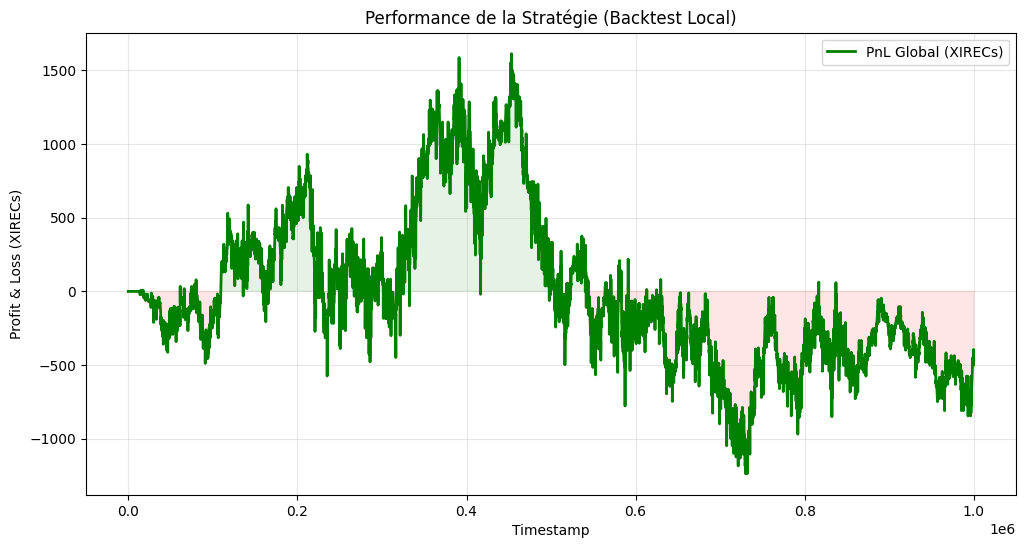

PnL Final : -467.00 XIRECs
Position finale EMERALDS : 0
Position finale TOMATOES : 36
Début du backtest sur prices_round_0_day_-2.csv...


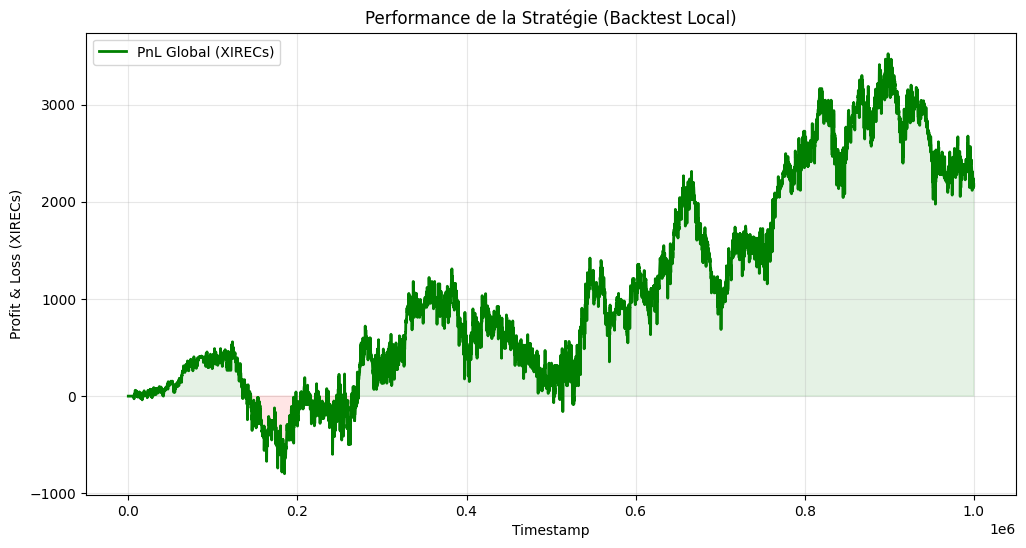

PnL Final : 2168.00 XIRECs
Position finale EMERALDS : 0
Position finale TOMATOES : 50


In [79]:
# backtest 

import pandas as pd
import matplotlib.pyplot as plt
from datamodel import OrderDepth, TradingState, Order
import json


def run_custom_backtest(csv_path, trader_class):
    print(f"Début du backtest sur {csv_path}...")
    
    # 1. Chargement et préparation des données
    df = pd.read_csv(csv_path, sep=';')
    df.sort_values(['timestamp', 'product'], inplace=True)
    
    # Remplacer les NaN par 0 pour les volumes
    vol_cols = ['bid_volume_1', 'bid_volume_2', 'bid_volume_3', 
                'ask_volume_1', 'ask_volume_2', 'ask_volume_3']
    df[vol_cols] = df[vol_cols].fillna(0)
    
    # Variables d'état globales
    trader = trader_class()
    traderData = ""
    positions = {"EMERALDS": 0, "TOMATOES": 0}
    cash = {"EMERALDS": 0.0, "TOMATOES": 0.0}
    pnl_history = []
    timestamps = []
    
    # Grouper par tick (timestamp)
    grouped = df.groupby('timestamp')
    
    # 2. Boucle de simulation Tick par Tick
    for timestamp, group in grouped:
        order_depths = {}
        mid_prices = {}
        
        # Construire le carnet d'ordres (OrderDepth) pour ce tick
        for _, row in group.iterrows():
            product = row['product']
            depth = OrderDepth()
            
            # Bids (Achats)
            for i in range(1, 4):
                price = row[f'bid_price_{i}']
                vol = row[f'bid_volume_{i}']
                if pd.notna(price) and vol > 0:
                    depth.buy_orders[int(price)] = int(vol)
                    
            # Asks (Ventes) - Rappel : dans Prosperity, les volumes ask sont négatifs
            for i in range(1, 4):
                price = row[f'ask_price_{i}']
                vol = row[f'ask_volume_{i}']
                if pd.notna(price) and vol != 0:
                    depth.sell_orders[int(price)] = int(vol) # Conserve le signe négatif
            
            order_depths[product] = depth
            mid_prices[product] = row['mid_price']
            
        # Créer l'état de trading
        state = TradingState(
            traderData=traderData,
            timestamp=timestamp,
            listings={},
            order_depths=order_depths,
            own_trades={},
            market_trades={},
            position=positions.copy(),
            observations={}
        )
        
        # 3. Appel de VOTRE stratégie
        orders_dict, conversions, traderData = trader.run(state)
        
        # 4. Moteur d'exécution (Matching Engine simplifié)
        for product, orders in orders_dict.items():
            depth = order_depths[product]
            
            for order in orders:
                qty = order.quantity
                
                # ORDRE D'ACHAT (qty > 0)
                if qty > 0:
                    # On trie les asks du moins cher au plus cher
                    asks = sorted(depth.sell_orders.items())
                    for ask_price, ask_vol in asks:
                        if order.price >= ask_price and qty > 0:
                            # Volume disponible (valeur absolue)
                            available_vol = abs(ask_vol)
                            traded = min(qty, available_vol)
                            
                            positions[product] += traded
                            cash[product] -= traded * ask_price
                            qty -= traded
                            
                # ORDRE DE VENTE (qty < 0)
                elif qty < 0:
                    qty_to_sell = abs(qty)
                    # On trie les bids du plus cher au moins cher
                    bids = sorted(depth.buy_orders.items(), reverse=True)
                    for bid_price, bid_vol in bids:
                        if order.price <= bid_price and qty_to_sell > 0:
                            traded = min(qty_to_sell, bid_vol)
                            
                            positions[product] -= traded
                            cash[product] += traded * bid_price
                            qty_to_sell -= traded

        # 5. Calcul du PnL (Mark-to-Market)
        total_pnl = 0
        for prod in positions.keys():
            if prod in mid_prices:
                # PnL = Cash + (Position Actuelle * Prix Actuel)
                prod_pnl = cash[prod] + (positions[prod] * mid_prices[prod])
                total_pnl += prod_pnl
                
        pnl_history.append(total_pnl)
        timestamps.append(timestamp)
        
    # 6. Visualisation des résultats
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps, pnl_history, label='PnL Global (XIRECs)', color='green', linewidth=2)
    plt.title("Performance de la Stratégie (Backtest Local)")
    plt.xlabel("Timestamp")
    plt.ylabel("Profit & Loss (XIRECs)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.fill_between(timestamps, pnl_history, 0, where=(pd.Series(pnl_history) >= 0), color='green', alpha=0.1)
    plt.fill_between(timestamps, pnl_history, 0, where=(pd.Series(pnl_history) < 0), color='red', alpha=0.1)
    plt.show()
    
    print(f"PnL Final : {pnl_history[-1]:.2f} XIRECs")
    print(f"Position finale EMERALDS : {positions['EMERALDS']}")
    print(f"Position finale TOMATOES : {positions['TOMATOES']}")
    
    return pnl_history, positions

# --- UTILISATION ---
# Assurez-vous que la classe Trader (celle que nous avons écrite précédemment) est bien exécutée dans une cellule au-dessus.
# Lancement :
pnl, pos = run_custom_backtest("prices_round_0_day_-1.csv", Trader)
pnl, pos = run_custom_backtest("prices_round_0_day_-2.csv", Trader)

Chargement de prices_round_0_day_-1.csv...


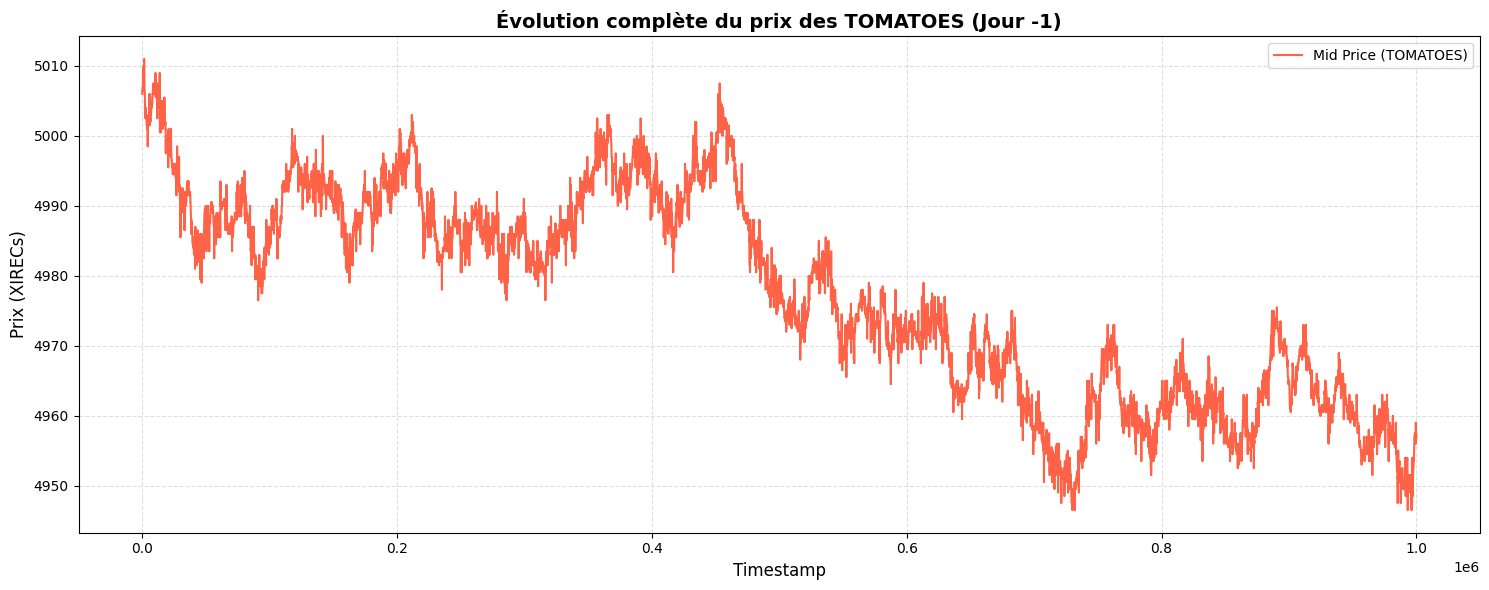

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement des données
csv_path = "prices_round_0_day_-1.csv"
print(f"Chargement de {csv_path}...")
df = pd.read_csv(csv_path, sep=';')

# 2. Filtrage pour isoler les TOMATOES
df_tomatoes = df[df['product'] == 'TOMATOES'].copy()

# 3. Création du graphique
plt.figure(figsize=(15, 6))

# On trace le Mid Price (le prix moyen entre l'achat et la vente)
plt.plot(df_tomatoes['timestamp'], df_tomatoes['mid_price'], 
         color='tomato', linewidth=1.5, label='Mid Price (TOMATOES)')

# 4. Esthétique et lisibilité
plt.title("Évolution complète du prix des TOMATOES (Jour -1)", fontsize=14, fontweight='bold')
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Prix (XIRECs)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()

# Affichage
plt.show()


Chargement de prices_round_0_day_-2.csv...


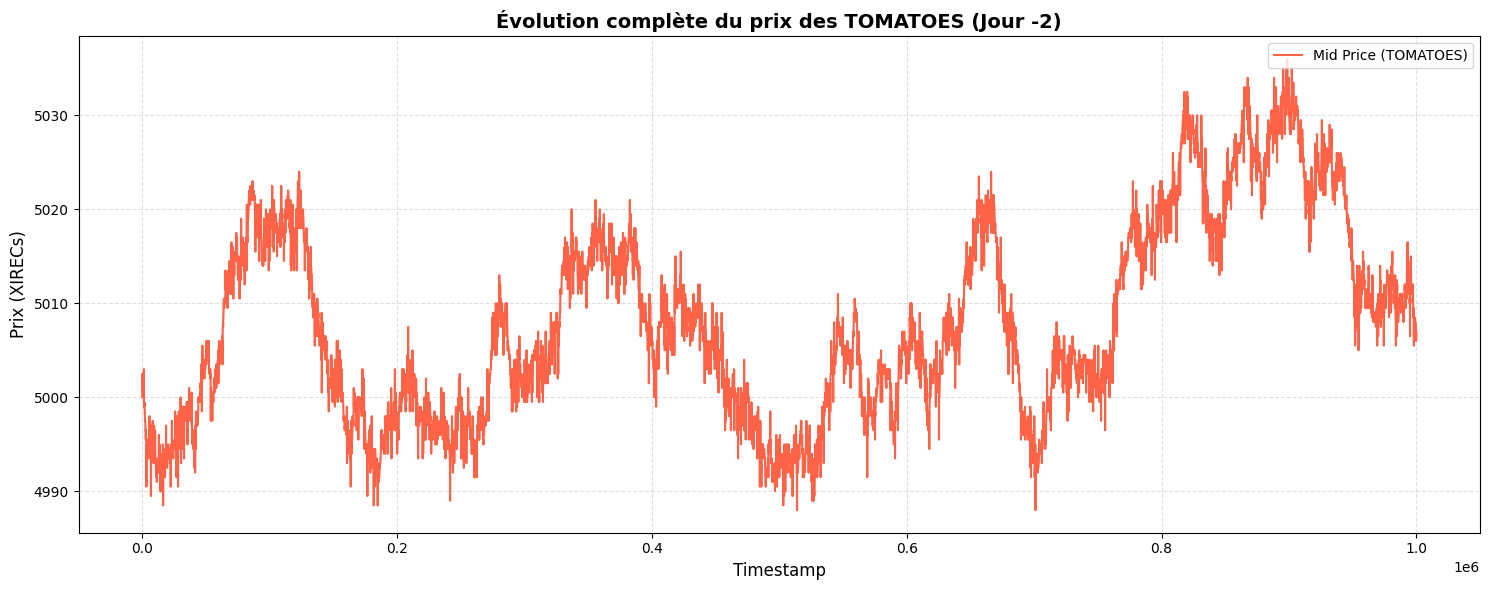

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement des données
csv_path = "prices_round_0_day_-2.csv"
print(f"Chargement de {csv_path}...")
df = pd.read_csv(csv_path, sep=';')

# 2. Filtrage pour isoler les TOMATOES
df_tomatoes = df[df['product'] == 'TOMATOES'].copy()

# 3. Création du graphique
plt.figure(figsize=(15, 6))

# On trace le Mid Price (le prix moyen entre l'achat et la vente)
plt.plot(df_tomatoes['timestamp'], df_tomatoes['mid_price'], 
         color='tomato', linewidth=1.5, label='Mid Price (TOMATOES)')

# 4. Esthétique et lisibilité
plt.title("Évolution complète du prix des TOMATOES (Jour -2)", fontsize=14, fontweight='bold')
plt.xlabel("Timestamp", fontsize=12)
plt.ylabel("Prix (XIRECs)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()

# Affichage
plt.show()
